In [1]:
import os
import numpy as np

import jax
import jax.numpy as jnp
from jax import jacfwd, vmap
from functools import partial
from typing import NamedTuple, Sequence, Callable

import flax.linen as nn
import optax
from soap_jax import soap

import time
import scipy.io
import matplotlib.pyplot as plt

from flax import serialization

from Utilities_talpinn_burgers1d_statistic import *

interface x = 0.5 index = 256


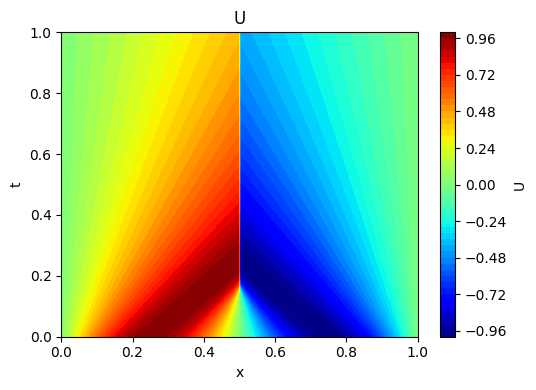

In [10]:
# 1. Data
data = scipy.io.loadmat("burgers_godunov.mat")
#data = scipy.io.loadmat("burgers_riemann.mat")

U0 = jnp.asarray(data["U"][::2,::2])
X0 = jnp.asarray(data["X"][::2,::2])
T0 = jnp.asarray(data["T"][::2,::2])

Nt_test, Nx_test = U0.shape

T_grid = T0
X_grid = X0

t_test = T0.reshape(-1)
x_test = X0.reshape(-1)
test_labels = U0.reshape(-1, 1)

x_unique = np.unique(np.asarray(X0))
interface_idx = int(np.argmin(np.abs(x_unique - 0.5)))

print("interface x =", x_unique[interface_idx], "index =", interface_idx)

plt.figure(figsize=(5.5, 4))
plt.contourf(X0, T0, U0, levels=50, cmap='jet')
plt.colorbar(label='U')
plt.xlabel('x')
plt.ylabel('t')
plt.title('U')
plt.tight_layout()
plt.show()

In [3]:
# 2. Random keys
seed = 47
key = jax.random.PRNGKey(seed)
(key_pde_init, key_coor_init, key_train) = jax.random.split(key, 3)

# 3. Models
layer_sizes = [40, 40, 1]

pde_net = FNN_fourier(layer_sizes, fourier_dim=20)
pde_params = pde_net.init(key_pde_init, jnp.ones((3,)))

coor_net = FNN_fourier(layer_sizes, fourier_dim=20)
coor_params = coor_net.init(key_coor_init, jnp.ones((2,)))

# 4. Optimizers
pde_optimizer = soap(learning_rate=3e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)
coor_optimizer = soap(learning_rate=3e-3, b1=0.95, b2=0.95, weight_decay=0.01, precondition_frequency=10, precondition_1d=False)

# 5. Common functions
pde_loss_grad_fn = create_pde_loss_grad_fn(pde_net)
coor_loss_grad_fn = create_coor_loss_grad_fn(coor_net, lambda_pos=0.01, xi_x_min=0.05)
eval_fn = create_eval_fn(pde_net, nx_test=Nx_test, interface_idx=interface_idx, interface_mode="drop")

[Stage 1] JIT warm-up finished.
[Stage 1] iter = 00000, time = 0.00s | mse = 9.39e-01, rl2 = 1.96e+00
[Stage 1] iter = 00100, time = 0.60s, loss = 3.07e-01 | mse = 3.84e-02, rl2 = 3.95e-01
[Stage 1] iter = 00200, time = 0.95s, loss = 1.24e-01 | mse = 2.23e-02, rl2 = 3.01e-01
[Stage 1] iter = 00300, time = 1.30s, loss = 8.07e-03 | mse = 1.04e-02, rl2 = 2.06e-01
[Stage 1] iter = 00400, time = 1.64s, loss = 1.53e-03 | mse = 9.81e-03, rl2 = 2.00e-01
[Stage 1] iter = 00500, time = 1.99s, loss = 6.78e-04 | mse = 9.72e-03, rl2 = 1.99e-01
[Stage 1] iter = 00600, time = 2.33s, loss = 5.44e-04 | mse = 9.69e-03, rl2 = 1.99e-01
[Stage 1] iter = 00700, time = 2.68s, loss = 3.43e-04 | mse = 9.70e-03, rl2 = 1.99e-01
[Stage 1] iter = 00800, time = 3.02s, loss = 2.61e-04 | mse = 9.67e-03, rl2 = 1.99e-01
[Stage 1] iter = 00900, time = 3.37s, loss = 2.66e-04 | mse = 9.66e-03, rl2 = 1.98e-01
[Stage 1] iter = 01000, time = 3.71s, loss = 1.99e-04 | mse = 9.66e-03, rl2 = 1.98e-01
[Stage 1] iter = 01100, time

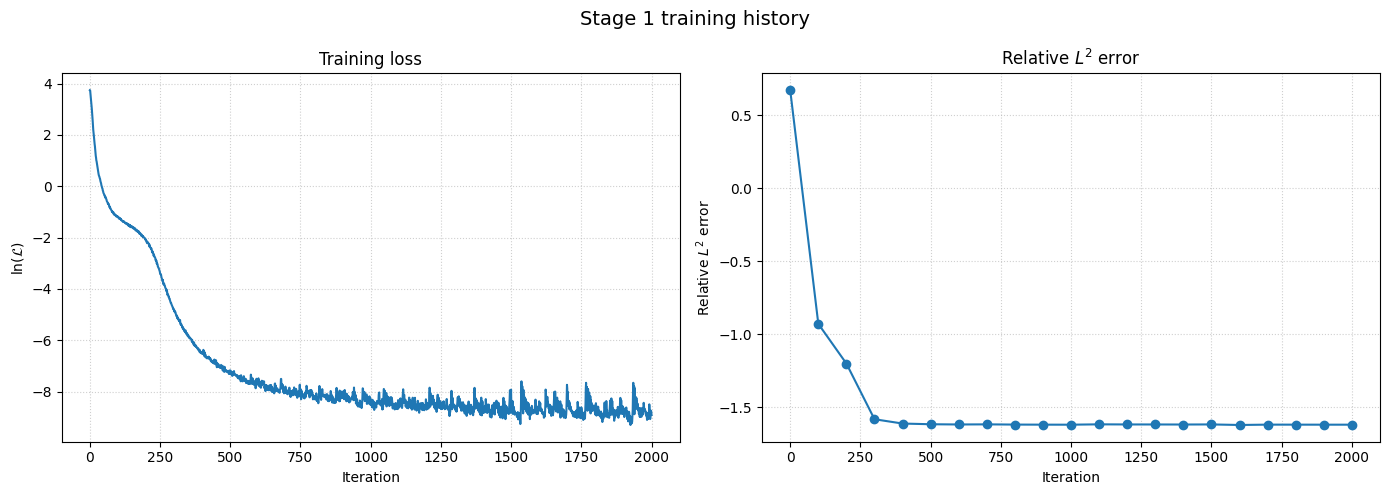

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 9.658489e-03
 RL2 = 1.983853e-01


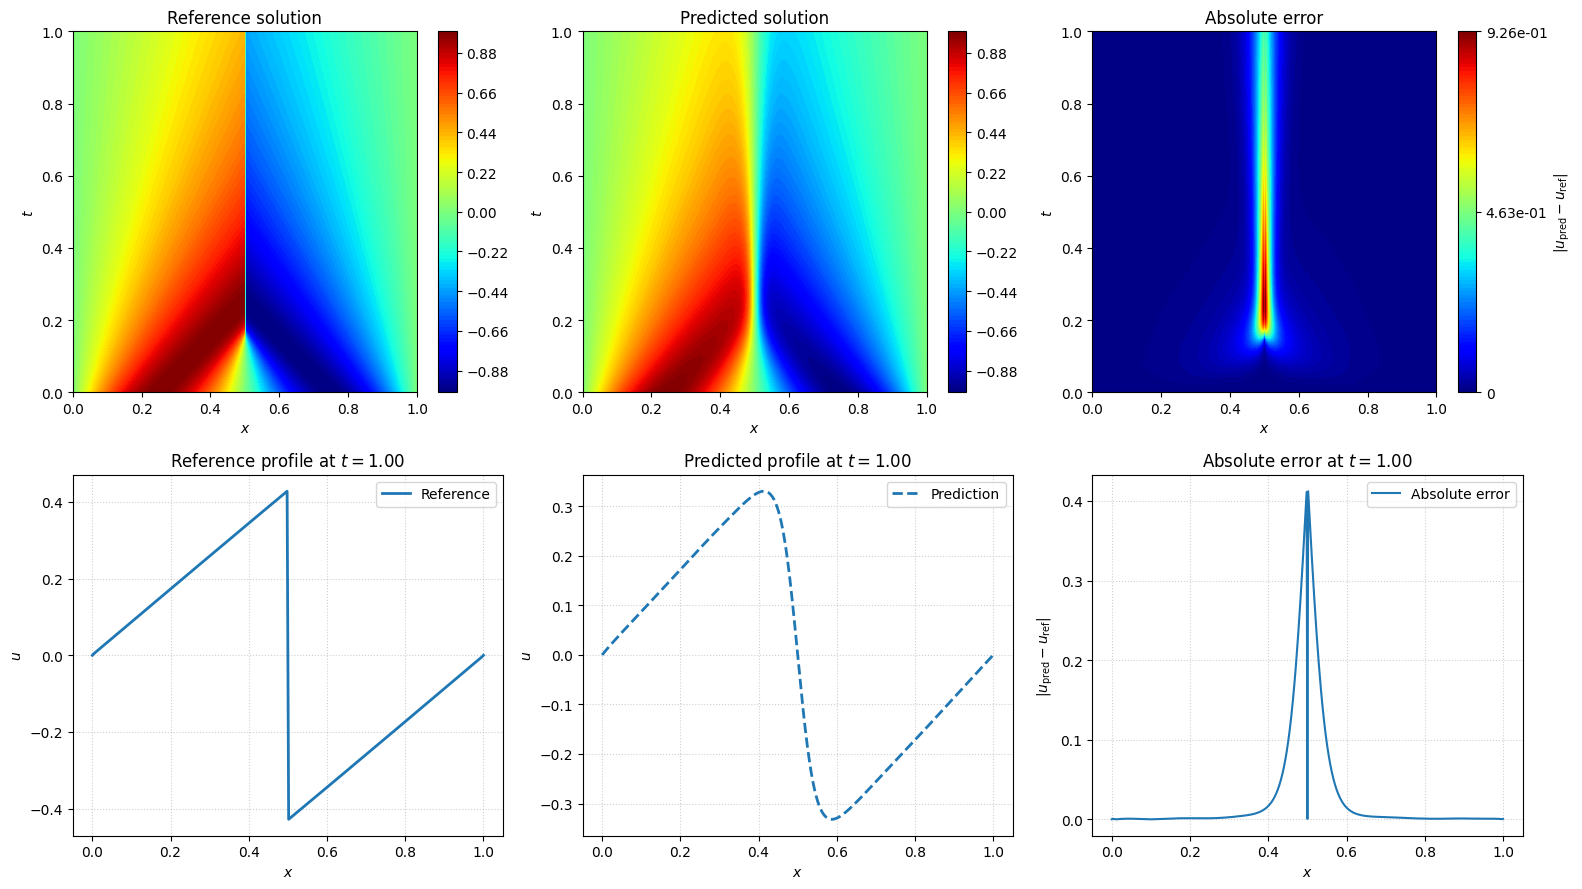

(np.float32(0.009658489), np.float32(0.19838525))

In [4]:
# Stage 1
test_inputs_stage1 = create_test_inputs(t_test, x_test, identity_coor_net)
minibatch_stage1 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, identity_map_xi_to_x, identity_coor_net)

pde_params, key_train, history_stage1 = train_pde_stage(stage_name="Stage 1", 
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage1,
    eval_fn=eval_fn, test_inputs=test_inputs_stage1, test_labels=test_labels, 
    key=key_train, nu=1e-2, max_iters=2000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

# JAX parameter PyTrees are immutable, so retaining the reference here is a
# valid snapshot even though ``pde_params`` is rebound in later stages.
pde_params_stage1 = pde_params

plot_training_history(history_stage1, metric="rl2", title="Stage 1 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, coor_fn=identity_coor_net, interface_x=0.5, 
    metric_interface_mode="drop", plot_interface_mode="none")

[Adaptive Mesh] time = 0.90 s
[Coordinate] JIT warm-up finished.
[Coordinate] iter = 01000, time = 1.93s, batch loss = 1.36e-06, full mse = 1.28e-06
[Coordinate] iter = 02000, time = 3.85s, batch loss = 7.95e-07, full mse = 1.15e-06
[Coordinate] iter = 03000, time = 5.77s, batch loss = 7.95e-07, full mse = 4.10e-07
[Coordinate] iter = 04000, time = 7.69s, batch loss = 6.61e-07, full mse = 7.89e-07
[Coordinate] iter = 05000, time = 9.61s, batch loss = 7.20e-07, full mse = 6.32e-07
[Coordinate] iter = 06000, time = 11.52s, batch loss = 4.81e-07, full mse = 7.55e-07
[Coordinate] iter = 07000, time = 13.44s, batch loss = 4.02e-07, full mse = 3.63e-07
[Coordinate] iter = 08000, time = 15.38s, batch loss = 1.10e-07, full mse = 3.97e-07
[Coordinate] iter = 09000, time = 17.34s, batch loss = 3.79e-07, full mse = 1.74e-07
[Coordinate] iter = 10000, time = 19.31s, batch loss = 1.50e-07, full mse = 1.43e-07
Coordinate MSE = 1.432523e-07
Coordinate max error = 1.787603e-03
xi_x min = 2.265660e-01


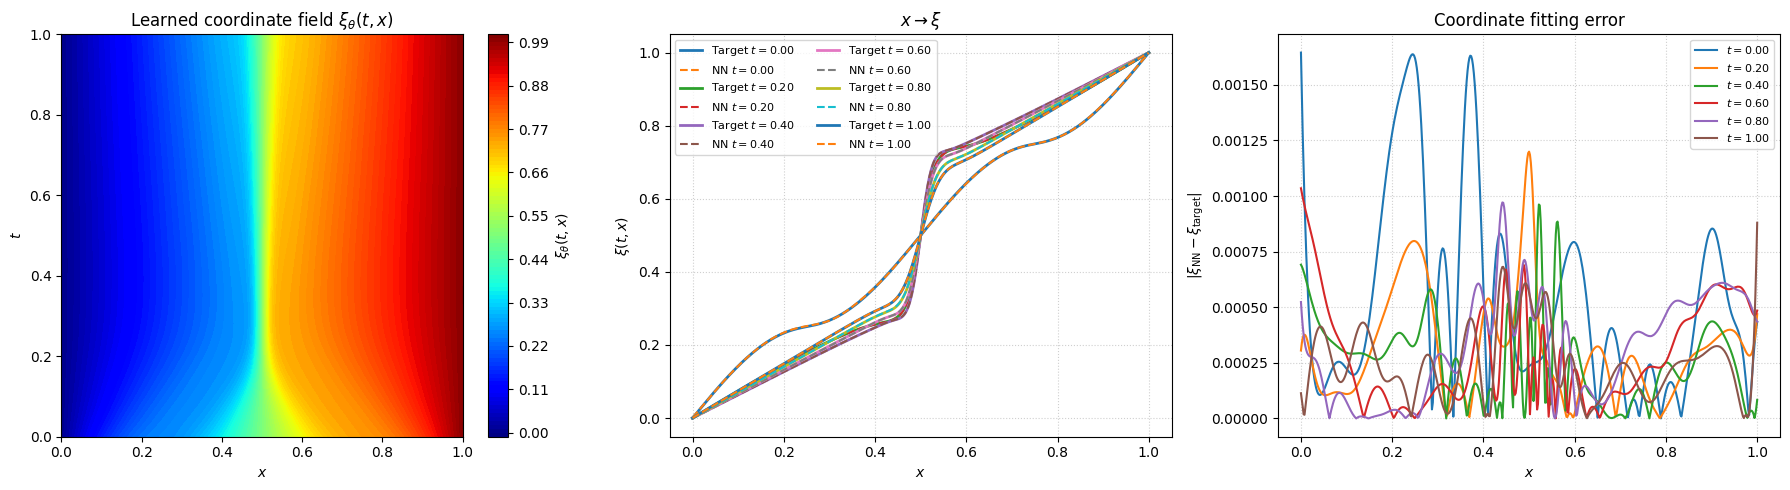

In [5]:
# Adaptive mesh
(xi_grid, Xi_of_x, X_adapt, map_xi_to_x, U_stage1) = generate_adaptive_mesh(pde_net, pde_params, T_grid, X_grid, identity_coor_net)

# Coordinate network
coor_params, key_train = train_coordinate_net(coor_net=coor_net, coor_params=coor_params, coor_optimizer=coor_optimizer, coor_loss_grad_fn=coor_loss_grad_fn,
    T_grid=T_grid, X_grid=X_grid, Xi_of_x=Xi_of_x, key=key_train, max_iters=10000, batch_size=10000, eval_every=1000)

coor_params_stage1 = coor_params

trained_coor_net = create_coor_fn(coor_net,coor_params)

plot_coordinate_mapping(T_grid=T_grid, X_grid=X_grid, xi_grid=xi_grid, Xi_of_x=Xi_of_x, X_adapt=X_adapt, coor_fn=trained_coor_net, n_times=6)

[Stage 2] JIT warm-up finished.
[Stage 2] iter = 00000, time = 0.00s | mse = 1.22e-02, rl2 = 2.23e-01
[Stage 2] iter = 00100, time = 0.39s, loss = 1.85e-01 | mse = 1.21e-02, rl2 = 2.22e-01
[Stage 2] iter = 00200, time = 0.76s, loss = 2.45e-02 | mse = 1.18e-03, rl2 = 6.94e-02
[Stage 2] iter = 00300, time = 1.13s, loss = 1.12e-02 | mse = 5.56e-04, rl2 = 4.76e-02
[Stage 2] iter = 00400, time = 1.50s, loss = 7.32e-03 | mse = 4.47e-04, rl2 = 4.27e-02
[Stage 2] iter = 00500, time = 1.87s, loss = 4.78e-03 | mse = 4.19e-04, rl2 = 4.13e-02
[Stage 2] iter = 00600, time = 2.24s, loss = 4.15e-03 | mse = 3.97e-04, rl2 = 4.02e-02
[Stage 2] iter = 00700, time = 2.61s, loss = 3.74e-03 | mse = 3.82e-04, rl2 = 3.94e-02
[Stage 2] iter = 00800, time = 2.98s, loss = 3.27e-03 | mse = 3.70e-04, rl2 = 3.88e-02
[Stage 2] iter = 00900, time = 3.34s, loss = 2.60e-03 | mse = 3.63e-04, rl2 = 3.85e-02
[Stage 2] iter = 01000, time = 3.71s, loss = 2.40e-03 | mse = 3.64e-04, rl2 = 3.85e-02
[Stage 2] iter = 01100, time

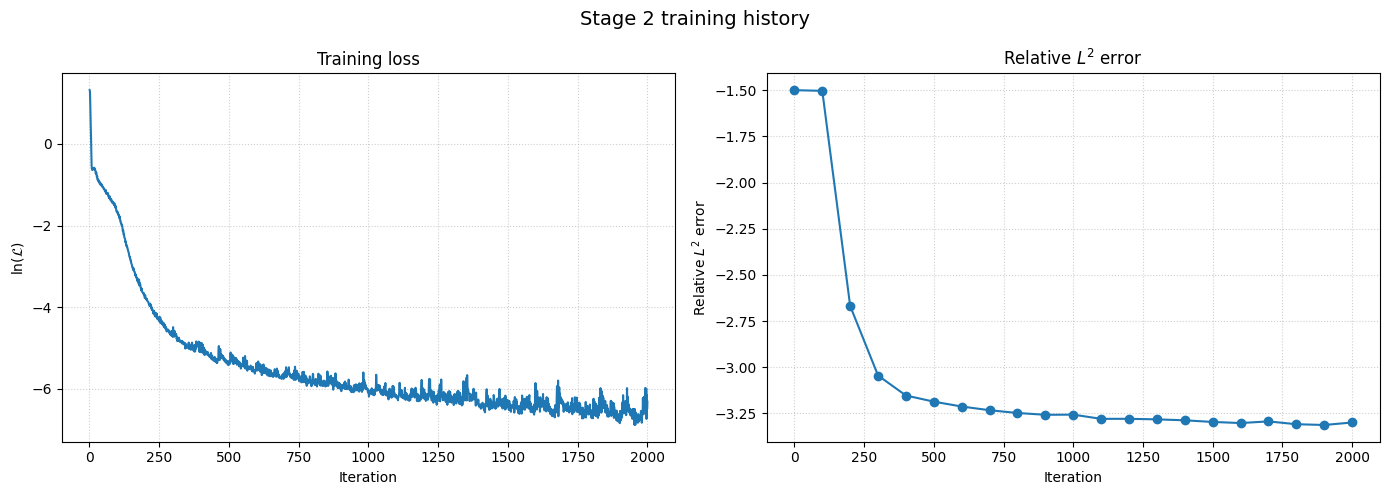

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 3.340605e-04
 RL2 = 3.689498e-02


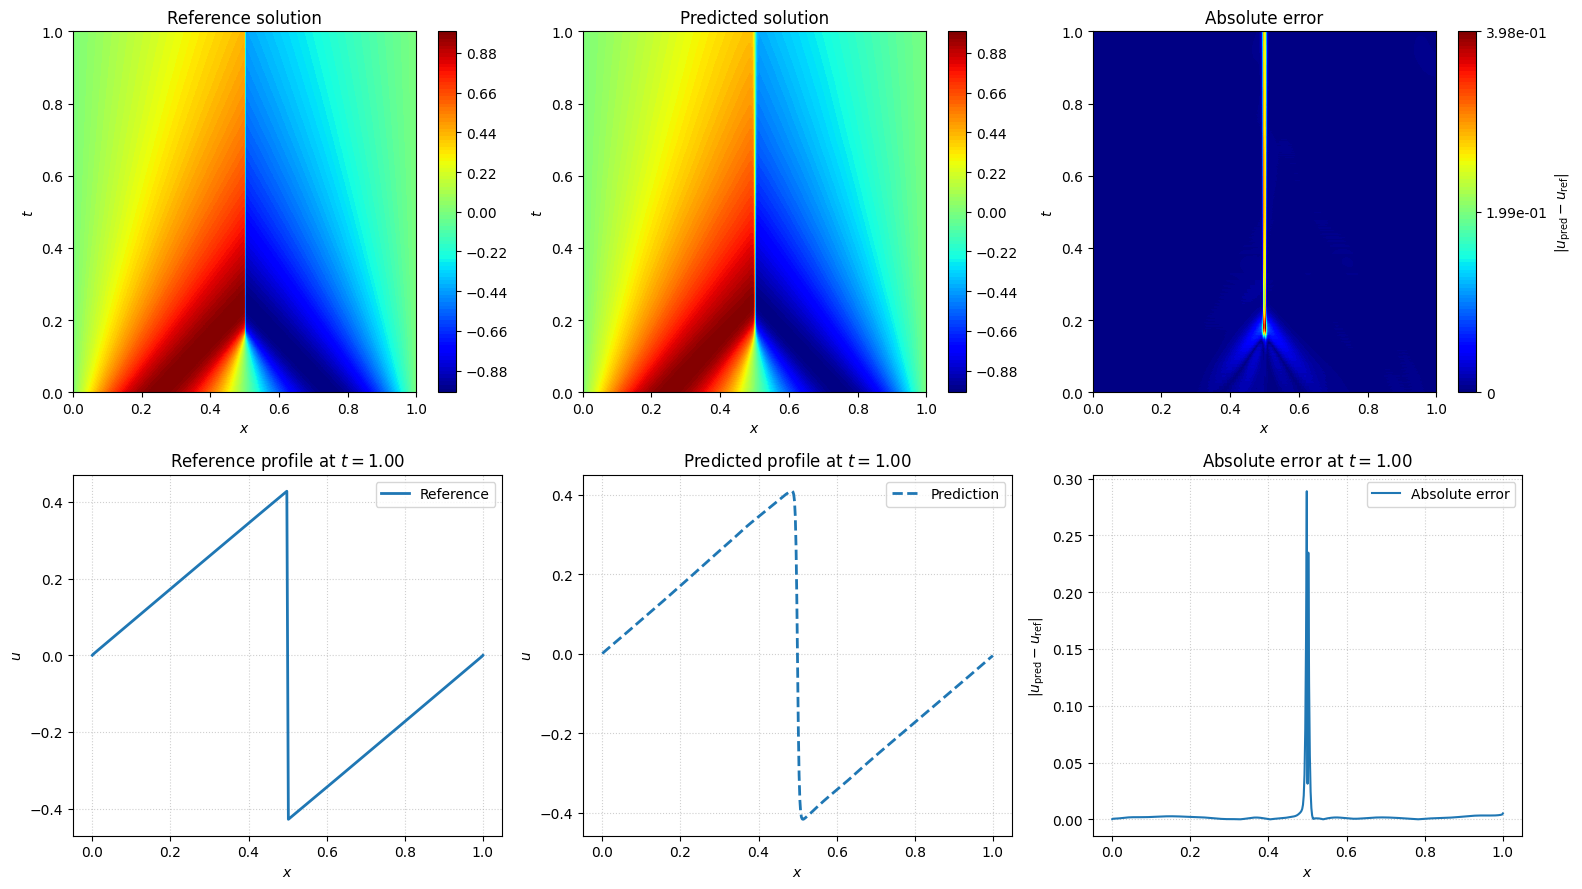

(np.float32(0.00033406046), np.float32(0.036894985))

In [6]:
# Stage 2
test_inputs_stage2 = create_test_inputs(t_test, x_test, trained_coor_net)
minibatch_stage2 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, map_xi_to_x, trained_coor_net)

pde_params, key_train, history_stage2 = train_pde_stage(stage_name="Stage 2",
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage2,
    eval_fn=eval_fn, test_inputs=test_inputs_stage2, test_labels=test_labels,
    key=key_train, nu=1e-3, max_iters=2000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage2 = pde_params

plot_training_history(history_stage2, metric="rl2", title="Stage 2 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, coor_fn=trained_coor_net, interface_x=0.5, 
    metric_interface_mode="drop", plot_interface_mode="none")

[Adaptive Mesh] time = 0.03 s
[Coordinate] JIT warm-up finished.
[Coordinate] iter = 01000, time = 1.95s, batch loss = 1.46e-06, full mse = 1.22e-06
[Coordinate] iter = 02000, time = 3.89s, batch loss = 6.39e-07, full mse = 8.74e-07
[Coordinate] iter = 03000, time = 5.83s, batch loss = 4.38e-07, full mse = 5.56e-07
[Coordinate] iter = 04000, time = 7.77s, batch loss = 4.49e-07, full mse = 1.24e-06
[Coordinate] iter = 05000, time = 9.72s, batch loss = 4.57e-07, full mse = 6.09e-07
[Coordinate] iter = 06000, time = 11.66s, batch loss = 4.63e-07, full mse = 4.74e-07
[Coordinate] iter = 07000, time = 13.61s, batch loss = 6.14e-07, full mse = 6.29e-07
[Coordinate] iter = 08000, time = 15.55s, batch loss = 3.54e-07, full mse = 7.34e-07
[Coordinate] iter = 09000, time = 17.49s, batch loss = 2.88e-07, full mse = 6.08e-07
[Coordinate] iter = 10000, time = 19.43s, batch loss = 4.97e-07, full mse = 6.20e-07
Coordinate MSE = 6.199787e-07
Coordinate max error = 7.425189e-03
xi_x min = 3.508554e-02


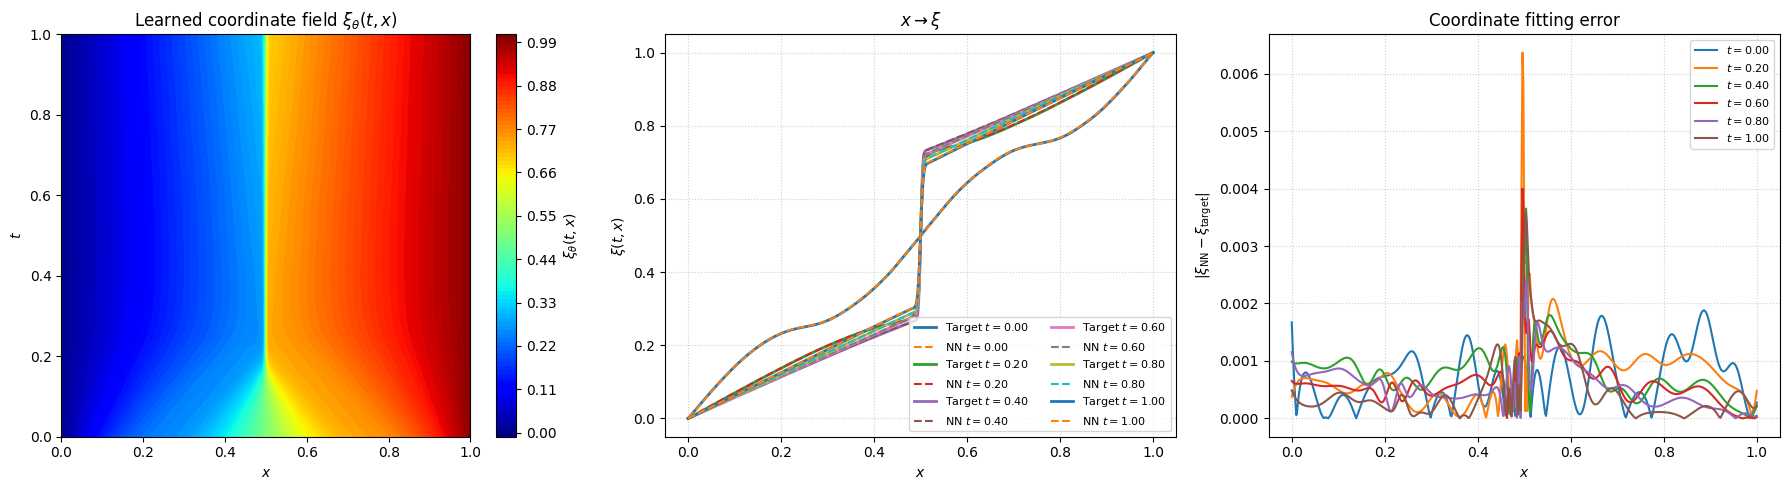

In [7]:
# Adaptive mesh
(xi_grid, Xi_of_x, X_adapt, map_xi_to_x, U_stage2) = generate_adaptive_mesh(pde_net, pde_params, T_grid, X_grid, trained_coor_net)

# Coordinate network
coor_params, key_train = train_coordinate_net(coor_net=coor_net, coor_params=coor_params, coor_optimizer=coor_optimizer, coor_loss_grad_fn=coor_loss_grad_fn,
    T_grid=T_grid, X_grid=X_grid, Xi_of_x=Xi_of_x, key=key_train, max_iters=10000, batch_size=10000, eval_every=1000)

coor_params_stage2 = coor_params

trained_coor_net = create_coor_fn(coor_net,coor_params)

plot_coordinate_mapping(T_grid=T_grid, X_grid=X_grid, xi_grid=xi_grid, Xi_of_x=Xi_of_x, X_adapt=X_adapt, coor_fn=trained_coor_net, n_times=6)

[Stage 3] JIT warm-up finished.
[Stage 3] iter = 00000, time = 0.00s | mse = 4.60e-04, rl2 = 4.33e-02
[Stage 3] iter = 00100, time = 0.37s, loss = 3.89e-01 | mse = 2.56e-02, rl2 = 3.23e-01
[Stage 3] iter = 00200, time = 0.73s, loss = 1.76e-01 | mse = 7.96e-03, rl2 = 1.80e-01
[Stage 3] iter = 00300, time = 1.09s, loss = 5.88e-02 | mse = 1.68e-03, rl2 = 8.27e-02
[Stage 3] iter = 00400, time = 1.45s, loss = 3.90e-02 | mse = 9.81e-04, rl2 = 6.32e-02
[Stage 3] iter = 00500, time = 1.81s, loss = 2.39e-02 | mse = 5.96e-04, rl2 = 4.93e-02
[Stage 3] iter = 00600, time = 2.17s, loss = 2.63e-02 | mse = 5.06e-04, rl2 = 4.54e-02
[Stage 3] iter = 00700, time = 2.53s, loss = 1.67e-02 | mse = 3.49e-04, rl2 = 3.77e-02
[Stage 3] iter = 00800, time = 2.89s, loss = 1.70e-02 | mse = 2.62e-04, rl2 = 3.27e-02
[Stage 3] iter = 00900, time = 3.25s, loss = 1.44e-02 | mse = 2.33e-04, rl2 = 3.08e-02
[Stage 3] iter = 01000, time = 3.61s, loss = 1.21e-02 | mse = 1.84e-04, rl2 = 2.74e-02
[Stage 3] iter = 01100, time

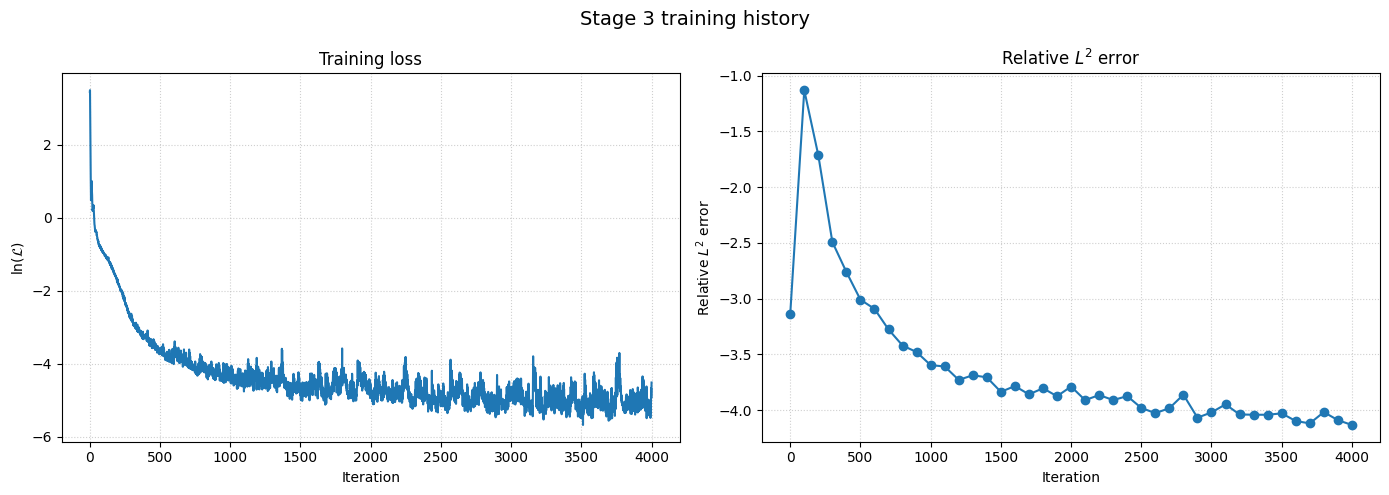

Plotting... Test grid shape: nt=513, nx=513
Interface detected at x = 0.50000000, index = 256
MSE = 6.298233e-05
 RL2 = 1.602006e-02


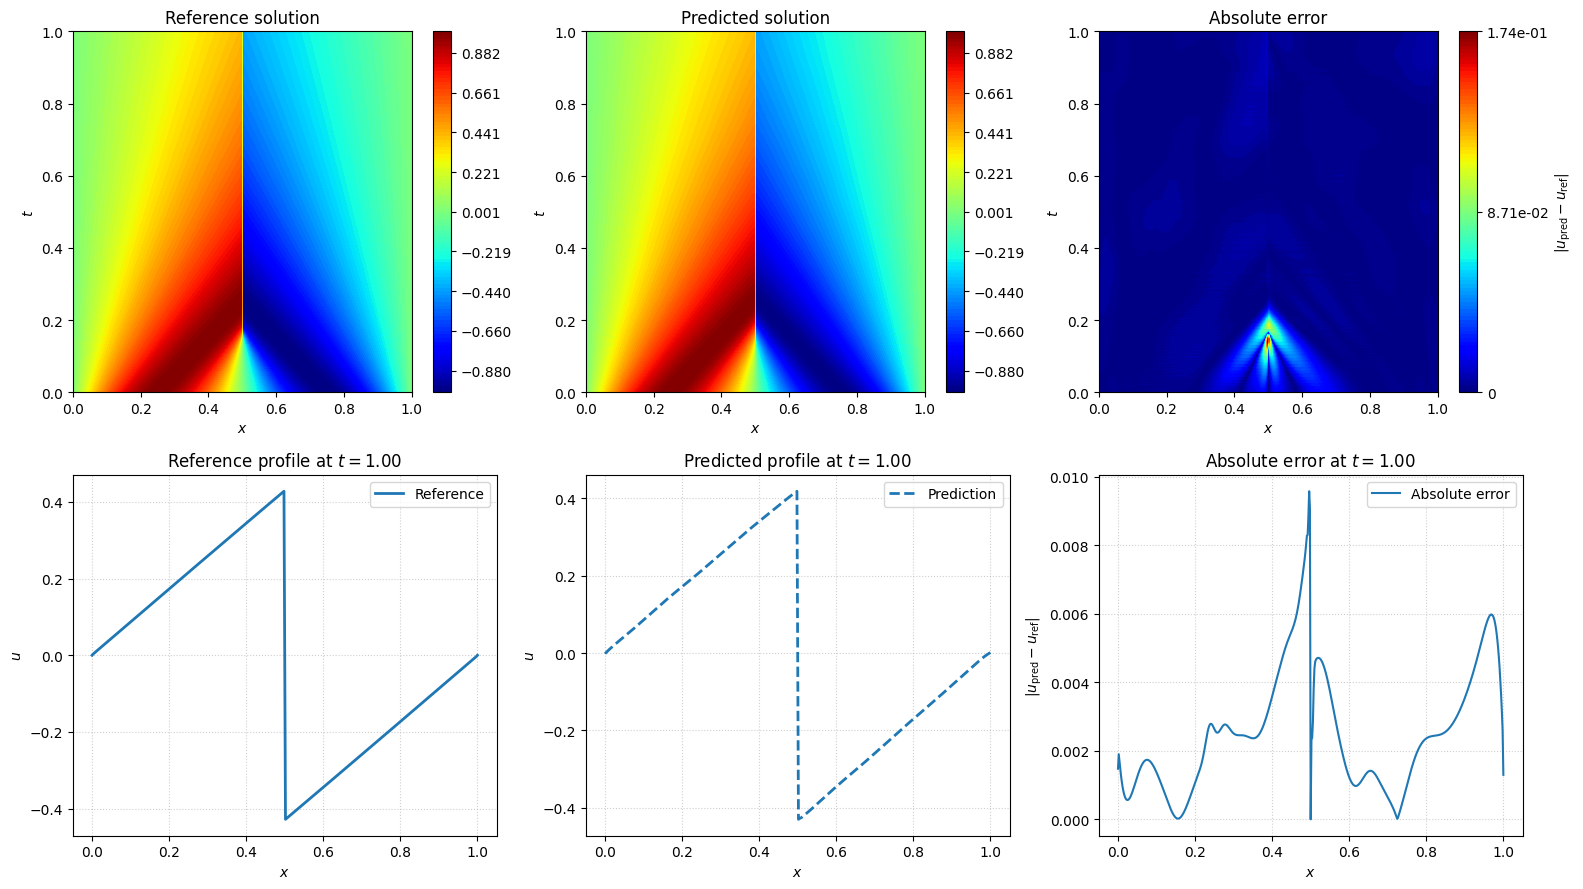

(np.float32(6.2982326e-05), np.float32(0.01602006))

In [8]:
# Stage 3
test_inputs_stage3 = create_test_inputs(t_test, x_test, trained_coor_net)
minibatch_stage3 = create_pde_minibatch_fn(IC_Burgers, BC_Burgers, map_xi_to_x, trained_coor_net)

pde_params, key_train, history_stage3 = train_pde_stage(stage_name="Stage 3",
    pde_params=pde_params, pde_optimizer=pde_optimizer, pde_loss_grad_fn=pde_loss_grad_fn, pde_minibatch_fn=minibatch_stage3,
    eval_fn=eval_fn, test_inputs=test_inputs_stage3, test_labels=test_labels,
    key=key_train, nu=1e-4, max_iters=4000, pts_pde=10000, pts_ics=1000, pts_bcs=1000, max_runtime=10000.0, eval_every=100)

pde_params_stage3 = pde_params

save_training_results(
    pde_params_by_stage={
        "stage1": pde_params_stage1,
        "stage2": pde_params_stage2,
        "stage3": pde_params_stage3,
    },
    coor_params_by_stage={
        "stage1": coor_params_stage1,
        "stage2": coor_params_stage2,
    },
    pde_histories_by_stage={
        "stage1": history_stage1,
        "stage2": history_stage2,
        "stage3": history_stage3,
    },
    checkpoint_path="talpinn_burgers_statistic11.msgpack",
)

plot_training_history(history_stage3, metric="rl2", title="Stage 3 training history")
plot_evaluation(params=pde_params, model=pde_net, t_test=t_test, x_test=x_test, labels_test=test_labels, coor_fn=trained_coor_net, interface_x=0.5, 
    metric_interface_mode="drop", plot_interface_mode="zero")